In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import tensorflow as tf

In [2]:
# Import dataset
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
# Understanding data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# Check missing values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [8]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [9]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [10]:
# Data Cleaning(Remove unnecessary ID)
df=df.drop("customerID",axis=1)

In [11]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

In [12]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [13]:
# Removing missing values
df=df.dropna()

In [14]:
df["TotalCharges"].isnull().sum()

np.int64(0)

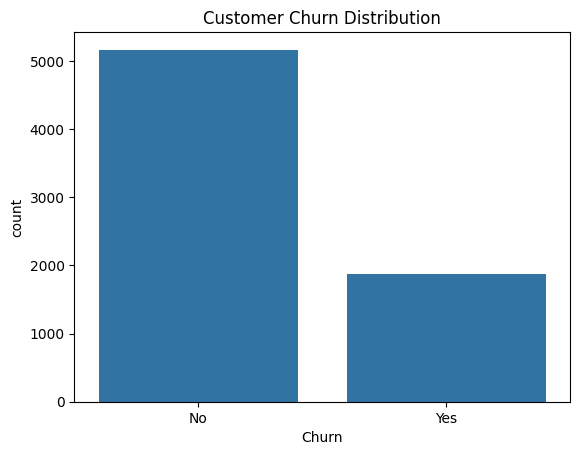

In [15]:
# Exploratory Data Analysis
#1.Analyse churn

sns.countplot(x=df["Churn"])
plt.title("Customer Churn Distribution")
plt.show()


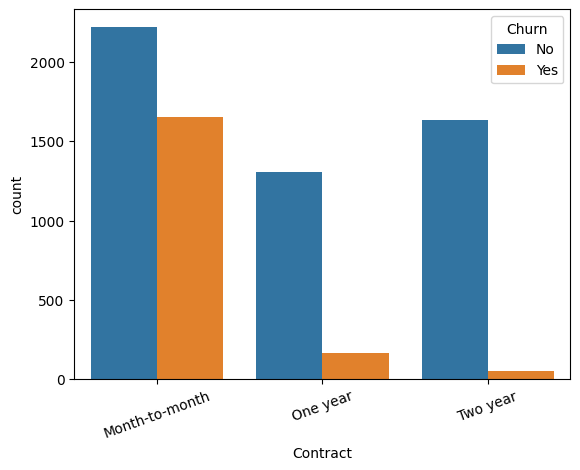

In [16]:
#2.Churn vs contract

sns.countplot(x="Contract",hue="Churn",data=df)
plt.xticks(rotation=20)
plt.show()

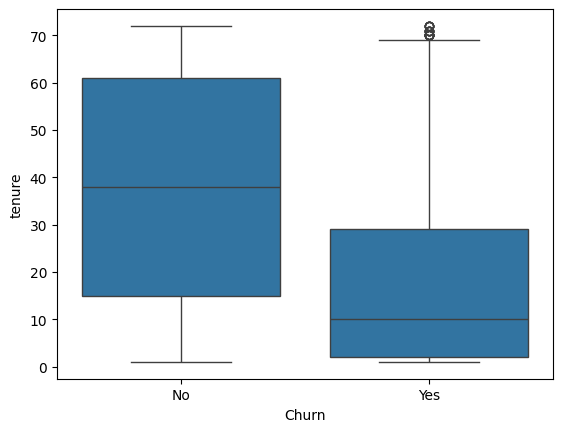

In [17]:
#3.Churn vs tenure

sns.boxplot(x="Churn",y="tenure",data=df)
plt.show()

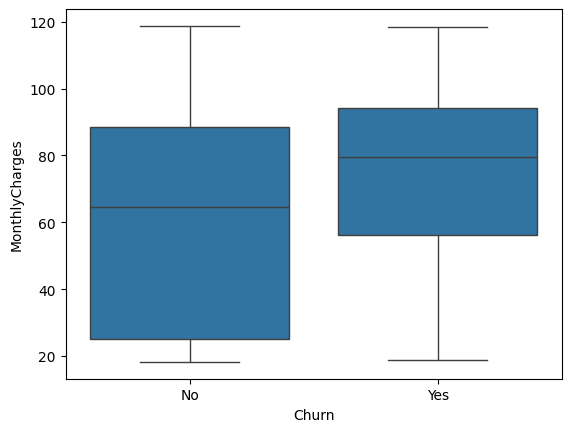

In [18]:
#4.Churn vs monthly charges

sns.boxplot(x="Churn",y="MonthlyCharges",data=df)
plt.show()

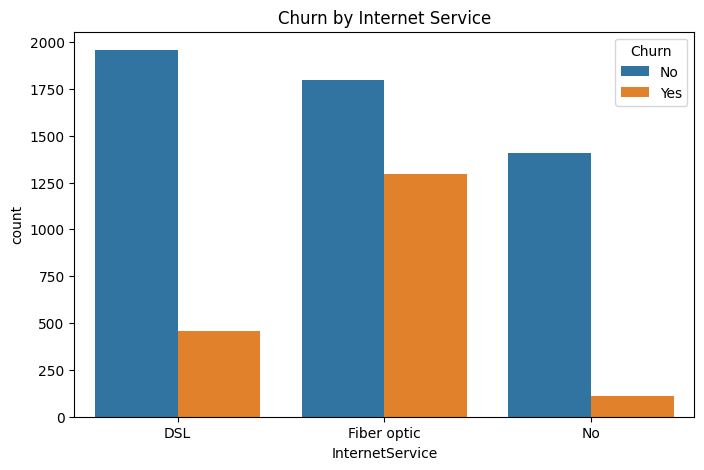

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title(
    "Churn by Internet Service"
)

plt.show()

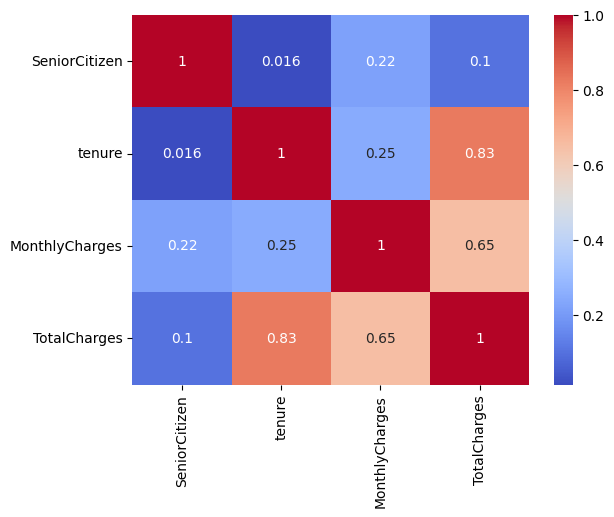

In [20]:
# Correlation

sns.heatmap(
    df.select_dtypes(include="number").corr(),cmap="coolwarm",annot=True
)
plt.show()

In [21]:
# Convert Churn to 0/1

df["Churn"]=df["Churn"].map({
    "Yes":1,
    "No":0
})

In [22]:
X=df.drop("Churn",axis=1)
y=df["Churn"]

In [23]:
# Encode categorical variables

#1.One hot encoding

X=pd.get_dummies(X,drop_first=True)

In [24]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [25]:
feature_names=X.columns.tolist()
joblib.dump(feature_names,"feature_names.pkl")

['feature_names.pkl']

In [26]:
# Train test split

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


In [27]:
# Scale the data (StandardScaler)

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [28]:
scaler.fit_transform(X_test)

array([[-0.44434987,  1.1055641 ,  0.39876937, ...,  1.89684981,
        -0.69470373, -0.56011203],
       [-0.44434987, -1.01268583,  0.48548888, ..., -0.52718987,
        -0.69470373, -0.56011203],
       [-0.44434987,  0.90188622, -1.46403224, ..., -0.52718987,
        -0.69470373,  1.78535711],
       ...,
       [-0.44434987, -1.17562813, -1.48571212, ..., -0.52718987,
        -0.69470373,  1.78535711],
       [-0.44434987,  0.20938144, -0.78195   , ..., -0.52718987,
        -0.69470373,  1.78535711],
       [-0.44434987,  0.73894392, -1.46236456, ...,  1.89684981,
        -0.69470373, -0.56011203]])

In [29]:
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [30]:
# Build a baseline model

from sklearn.linear_model import LogisticRegression

lr=LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled,y_train)


LogisticRegression(max_iter=1000)

In [31]:
# Build the ANN

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout

model=Sequential([
    Dense(64,activation="relu",input_shape=(X_train.shape[1],)),
    Dropout(0.30),
    Dense(32,activation="relu"),
    Dropout(0.20),
    Dense(16,activation="relu"),
    Dense(1,activation="sigmoid")
])





/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
# Compile ANN

model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy",tf.keras.metrics.AUC(name="auc")])

In [33]:
# Train ANN

from tensorflow.keras.callbacks import EarlyStopping
early_stopping=EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)



In [34]:
history=model.fit(
    X_train_scaled,y_train,
    validation_split=0.20,epochs=100,batch_size=32,
    callbacks=[early_stopping],verbose=1
)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7298 - auc: 0.7451 - loss: 0.5159 - val_accuracy: 0.7813 - val_auc: 0.8327 - val_loss: 0.4274
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7840 - auc: 0.8169 - loss: 0.4480 - val_accuracy: 0.7876 - val_auc: 0.8452 - val_loss: 0.4140
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7924 - auc: 0.8275 - loss: 0.4379 - val_accuracy: 0.7911 - val_auc: 0.8503 - val_loss: 0.4101
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7993 - auc: 0.8334 - loss: 0.4319 - val_accuracy: 0.7938 - val_auc: 0.8497 - val_loss: 0.4117
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8000 - auc: 0.8315 - loss: 0.4322 - val_accuracy: 0.7938 - val_auc: 0.8511 - val_loss: 0.4121
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7984 - auc: 0.8375 - loss: 0.4268 - val_accuracy: 0.7982 - val_auc: 0.8503 - val_loss: 0.4098
Epoch 7/100
141/141 ━━━━━━━━━━━━━━

In [35]:
# Generate predictions

y_probability=model.predict(X_test_scaled)
y_prediction=(y_probability >=0.5).astype(int)


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [36]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

print("Accuracy:",accuracy_score(y_test,y_prediction))
print("Precision:",precision_score(y_test,y_prediction))
print("Recall:",recall_score(y_test,y_prediction))
print("F1 Score:",f1_score(y_test,y_prediction))
print("ROC-AUC:",roc_auc_score(y_test,y_probability))

Accuracy: 0.7945984363894811
Precision: 0.6299694189602446
Recall: 0.5508021390374331
F1 Score: 0.5877318116975749
ROC-AUC: 0.8308286440511257


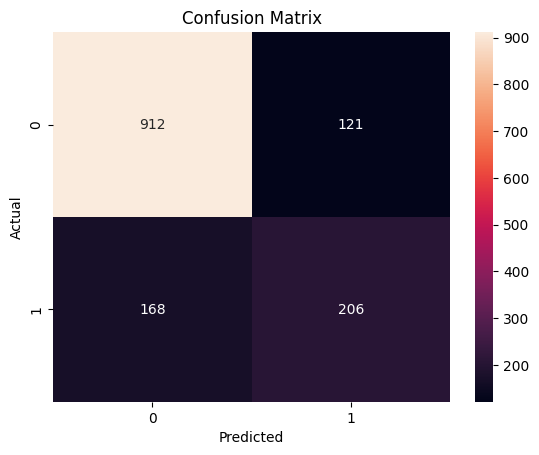

In [37]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_prediction)

sns.heatmap(cm,annot=True,fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


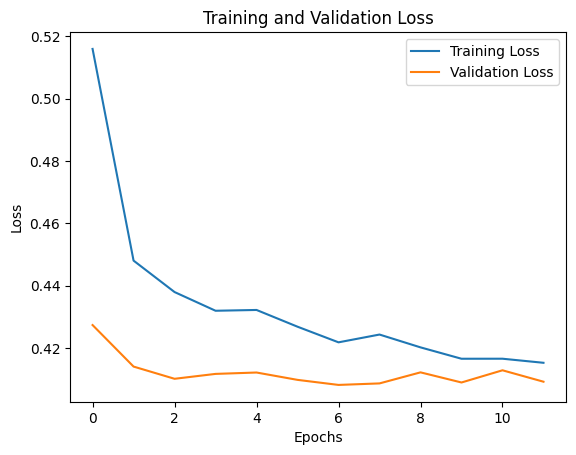

In [38]:
# Check Overfitting

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["Training Loss","Validation Loss"])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.show()

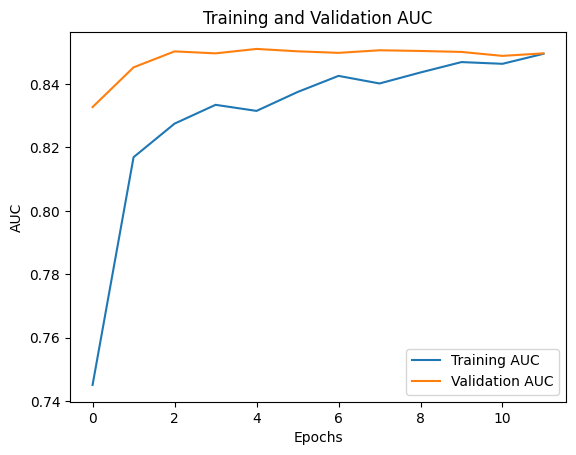

In [39]:
plt.plot(history.history["auc"])
plt.plot(history.history["val_auc"])
plt.legend(["Training AUC","Validation AUC"])
plt.xlabel("Epochs")
plt.ylabel("AUC")
plt.title("Training and Validation AUC")
plt.show()

In [40]:
# Save the ANN(Don't use .pkl for tensorflow ANN)

model.save("churn_ann.keras")
